In [1]:
import pandas as pd
import io
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
file_name = "CleanNormalizadedDataset.csv"

try:
    df = pd.read_csv(file_name)
    print(f'Archivo "{file_name}" cargado exitosamente.')
    display(df.head())
except FileNotFoundError:
    print(f"Error: El archivo '{file_name}' no se encontró. Asegúrate de que el nombre del archivo sea correcto")
except Exception as e:
    print(f"Ocurrió un error al leer el archivo: {e}")

Archivo "CleanNormalizadedDataset.csv" cargado exitosamente.


,COLE_BILINGUE,FAMI_TIENEAUTOMOVIL,FAMI_TIENECOMPUTADOR,FAMI_TIENEINTERNET,FAMI_TIENELAVADORA,PUNT_INGLES,PUNT_MATEMATICAS,PUNT_SOCIALES_CIUDADANAS,PUNT_C_NATURALES,PUNT_LECTURA_CRITICA,...,ESTU_DEPTO_RESIDE_SUCRE,ESTU_DEPTO_RESIDE_TOLIMA,ESTU_DEPTO_RESIDE_VALLE,ESTU_DEPTO_RESIDE_VAUPES,ESTU_DEPTO_RESIDE_VICHADA,ESTU_GENERO_M,FAMI_CUARTOSCASA,FAMI_PERSONASCASA,DENSIDADHOGAR,MAX_EDU_PADRES
0,0,0,1,1,1,71.0,66.0,70.0,65.0,69.0,...,False,False,False,False,False,False,2,1.5,0.75,9.0
1,0,0,1,1,1,71.0,66.0,70.0,65.0,69.0,...,False,False,False,False,False,False,2,1.5,0.75,9.0
2,0,0,0,0,0,46.0,43.0,31.0,40.0,43.0,...,False,False,False,False,False,False,2,5.5,2.75,1.0
3,0,0,0,0,0,46.0,43.0,31.0,40.0,43.0,...,False,False,False,False,False,False,2,5.5,2.75,1.0
4,0,1,1,1,1,59.0,57.0,46.0,57.0,57.0,...,False,False,True,False,False,True,4,5.0,1.25,4.0


In [3]:
df = df.drop(columns=['PUNT_GLOBAL', 'FAMI_TIENELAVADORA','FAMI_EDUMADRE', 'FAMI_EDUPADRE','FAMI_CUARTOSCASA'])

In [4]:
df_copy = df.copy()

In [5]:
df_sample = df.sample(300000, random_state=42)

In [6]:
targets = [
    'PUNT_INGLES',
    'PUNT_MATEMATICAS',
    'PUNT_SOCIALES_CIUDADANAS',
    'PUNT_C_NATURALES',
    'PUNT_LECTURA_CRITICA'
]

In [7]:
X = df.drop(columns=targets)
y = df[targets]

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42)

In [9]:
print(X_train.shape, X_test.shape, X_val.shape)

(2527536, 56) (789855, 56) (631884, 56)


In [10]:
print(X_train.shape, y_train.shape)

(2527536, 56) (2527536, 5)


In [22]:
from sklearn.preprocessing import StandardScaler

scaler_y = StandardScaler()

# Fit SOLO con train
y_train = scaler_y.fit_transform(y_train)

# Transformar val y test
y_val = scaler_y.transform(y_val)
y_test = scaler_y.transform(y_test)

In [12]:
scaler_X = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
X_test = scaler_X.transform(X_test)

In [13]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [14]:
from tensorflow.keras import regularizers

model = Sequential([
    Dense(64, activation='relu',
          kernel_regularizer=regularizers.l2(0.001),
          input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation='relu'),

    Dense(5)
])

d:\TalentoTech - IA\Proyecto\proySaber\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='mse',
    metrics=['mae']
)

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),  # 👈 clave aquí
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 15s 3ms/step - loss: 15.1991 - mae: 1.7960 - val_loss: 0.9061 - val_mae: 0.7017
Epoch 2/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.8842 - mae: 0.6955 - val_loss: 0.7651 - val_mae: 0.6583
Epoch 3/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.7475 - mae: 0.6648 - val_loss: 0.6946 - val_mae: 0.6527
Epoch 4/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.7001 - mae: 0.6599 - val_loss: 0.6760 - val_mae: 0.6515
Epoch 5/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.6894 - mae: 0.6578 - val_loss: 0.6720 - val_mae: 0.6505
Epoch 6/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 14s 3ms/step - loss: 0.6836 - mae: 0.6554 - val_loss: 0.6688 - val_mae: 0.6491
Epoch 7/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.6808 - mae: 0.6543 - val_loss: 0.6663 - val_mae: 0.6472
Epoch 8/20
4937/4937 ━━━━━━━━━━━━━━━━━━━━ 16s 3ms/step - loss: 0.6791 - mae: 0.6536 - val_loss: 0.6654 - val_mae: 0.6466
Epoch 9/20
4937/4937 ━━━━━━━━━━

In [24]:
loss, mae = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test MAE:", mae)

24683/24683 ━━━━━━━━━━━━━━━━━━━━ 36s 1ms/step - loss: 0.6601 - mae: 0.6448
Test Loss: 0.6601332426071167
Test MAE: 0.6448025703430176


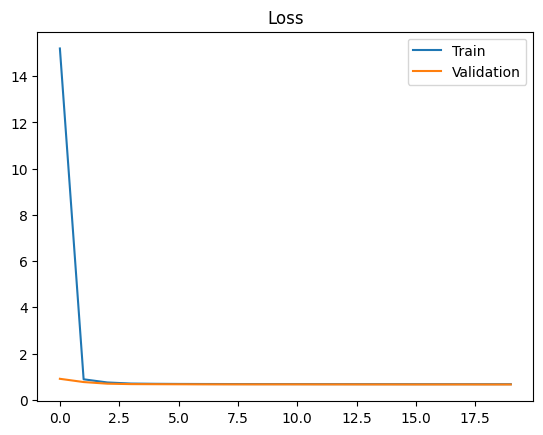

In [25]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Loss")
plt.show()

In [40]:
y_pred_scaled = model.predict(X_test)

24683/24683 ━━━━━━━━━━━━━━━━━━━━ 18s 736us/step


In [41]:
y_pred = scaler_y.inverse_transform(y_pred_scaled)

In [42]:
print(y_pred[:5])

[[49.38055  51.075024 48.71609  49.81427  53.400116]
 [41.319077 44.854618 40.201996 43.53354  46.098553]
 [50.90139  54.52793  48.28495  50.985947 53.623493]
 [54.513836 54.64335  53.998577 54.782364 53.896217]
 [44.808117 49.419384 43.766403 46.738205 49.642338]]


In [43]:
y_test_real = scaler_y.inverse_transform(y_test)

In [44]:
print(y_test_real[:5])

[[42. 58. 63. 52. 64.]
 [39. 33. 27. 34. 30.]
 [57. 60. 38. 46. 43.]
 [64. 65. 72. 68. 67.]
 [64. 63. 55. 62. 67.]]


In [45]:
for i, col in enumerate(targets):
    mae = np.mean(np.abs(y_test_real[:, i] - y_pred[:, i]))
    print(f"MAE {col}: {mae:.2f}")

MAE PUNT_INGLES: 7.65
MAE PUNT_MATEMATICAS: 7.89
MAE PUNT_SOCIALES_CIUDADANAS: 8.04
MAE PUNT_C_NATURALES: 6.87
MAE PUNT_LECTURA_CRITICA: 6.94


In [48]:
from sklearn.metrics import mean_squared_error

for i, col in enumerate(targets):
    rmse = np.sqrt(mean_squared_error(y_test_real[:, i], y_pred[:, i]))
    print(f"RMSE {col}: {rmse:.2f}")

RMSE PUNT_INGLES: 9.76
RMSE PUNT_MATEMATICAS: 9.92
RMSE PUNT_SOCIALES_CIUDADANAS: 9.97
RMSE PUNT_C_NATURALES: 8.61
RMSE PUNT_LECTURA_CRITICA: 8.68


In [50]:
from sklearn.metrics import r2_score

for i, col in enumerate(targets):
    r2 = r2_score(y_test_real[:, i], y_pred[:, i])
    print(f"R2 {col}: {r2:.3f}")

R2 PUNT_INGLES: 0.425
R2 PUNT_MATEMATICAS: 0.346
R2 PUNT_SOCIALES_CIUDADANAS: 0.301
R2 PUNT_C_NATURALES: 0.346
R2 PUNT_LECTURA_CRITICA: 0.304


In [52]:
import pandas as pd

df_results = pd.DataFrame()

for i, col in enumerate(targets):
    df_results[f"{col}_REAL"] = y_test_real[:, i]
    df_results[f"{col}_PRED"] = y_pred[:, i]

df_results.head(10)

,PUNT_INGLES_REAL,PUNT_INGLES_PRED,PUNT_MATEMATICAS_REAL,PUNT_MATEMATICAS_PRED,PUNT_SOCIALES_CIUDADANAS_REAL,PUNT_SOCIALES_CIUDADANAS_PRED,PUNT_C_NATURALES_REAL,PUNT_C_NATURALES_PRED,PUNT_LECTURA_CRITICA_REAL,PUNT_LECTURA_CRITICA_PRED
0,42.0,49.380550,58.0,51.075024,63.0,48.716091,52.0,49.814270,64.0,53.400116
1,39.0,41.319077,33.0,44.854618,27.0,40.201996,34.0,43.533539,30.0,46.098553
2,57.0,50.901390,60.0,54.527931,38.0,48.284950,46.0,50.985947,43.0,53.623493
3,64.0,54.513836,65.0,54.643349,72.0,53.998577,68.0,54.782364,67.0,53.896217
4,64.0,44.808117,63.0,49.419384,55.0,43.766403,62.0,46.738205,67.0,49.642338
5,55.0,54.997162,57.0,56.106216,61.0,54.589573,55.0,55.958851,55.0,54.991684
6,35.0,49.408985,39.0,50.524616,49.0,49.815434,41.0,50.195091,44.0,50.216564
7,41.0,53.622280,37.0,52.386639,53.0,53.144985,43.0,53.165970,41.0,53.874817
8,44.0,45.504139,50.0,44.733868,57.0,44.103878,46.0,45.051495,49.0,44.629509
9,59.0,69.424171,68.0,66.236969,74.0,62.794949,61.0,63.649048,65.0,64.268806


In [53]:
for i, col in enumerate(targets):
    df_results[f"{col}_ERROR"] = abs(
        df_results[f"{col}_REAL"] - df_results[f"{col}_PRED"]
    )

In [54]:
print(df_results[[f"{col}_ERROR" for col in targets]].describe())

       PUNT_INGLES_ERROR  PUNT_MATEMATICAS_ERROR  \
count      789855.000000           789855.000000   
mean            7.654025                7.890404   
std             6.049282                6.016162   
min             0.000069                0.000050   
25%             3.037367                3.165703   
50%             6.359856                6.681061   
75%            10.823118               11.326509   
max            61.031410               58.138008   

       PUNT_SOCIALES_CIUDADANAS_ERROR  PUNT_C_NATURALES_ERROR  \
count                   789855.000000           789855.000000   
mean                         8.040080                6.865978   
std                          5.901823                5.197990   
min                          0.000015                0.000046   
25%                          3.315544                2.758455   
50%                          6.941689                5.816525   
75%                         11.607841                9.877640   
max        

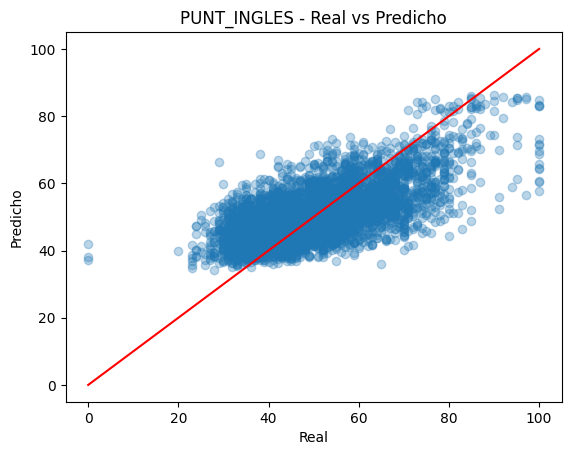

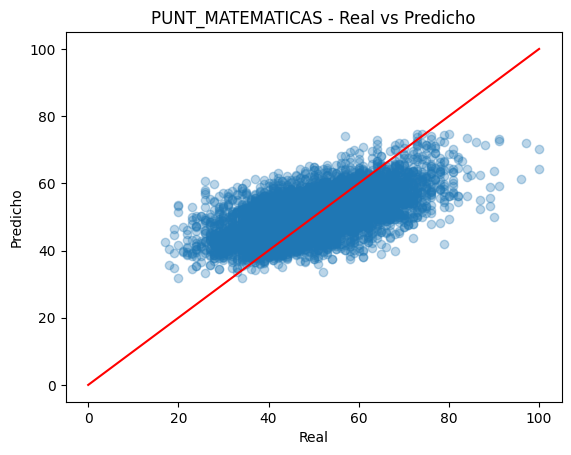

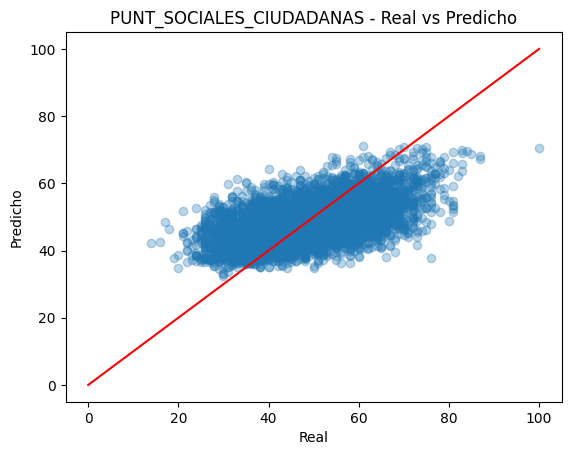

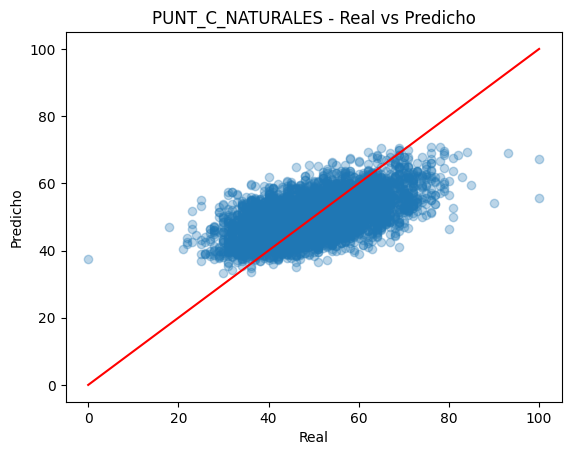

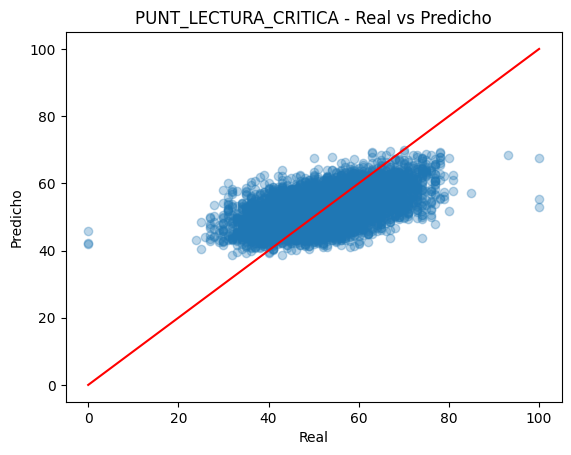

In [60]:
sample_idx = np.random.choice(len(y_test_real), 5000, replace=False)

for i, col in enumerate(targets):
    plt.scatter(
        y_test_real[sample_idx, i],
        y_pred[sample_idx, i],
        alpha=0.3
    )
    plt.plot([0,100], [0,100], color='red')  # línea ideal
    plt.xlabel("Real")
    plt.ylabel("Predicho")
    plt.title(f"{col} - Real vs Predicho")
    plt.show()